In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from scipy.io import loadmat
from torch.utils.data import DataLoader, TensorDataset
import multiprocessing
from matplotlib import pyplot as plt
import numpy as np
from scipy.io import loadmat
import functions as f

['alder', 'beech', 'birch', 'chestnut', 'ginkgo biloba', 'hornbeam', 'horse chestnut', 'linden', 'oak', 'oriental plane', 'pine', 'spruce']
(15408, 3, 40, 40)
[ 0  0  0 ... 11 11 11]


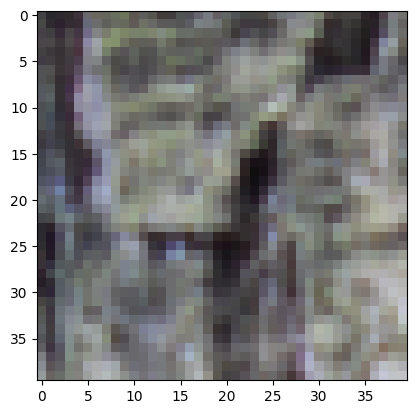

In [97]:
mat = loadmat('matlab/new_data1.mat')

train_data = mat['train_data']

train_labels = mat['train_labels']
test_data = mat['test_data']
test_labels = mat['test_labels']
classes = mat['classes']
classes = [c[0] for c in classes[0]]

print(classes)

# The training data has shape (40, 40, 3, 15408), Reshape to (samples, channels, height, widht) = (15408, 3, 40, 40)
train_data = np.transpose(train_data, (3, 2, 0, 1))
test_data = np.transpose(test_data, (3, 2, 0, 1))

plt.imshow(train_data[0].transpose(1, 2, 0))
train_data_raw_unormalized = train_data

print(train_data.shape)
train_labels = train_labels.squeeze() - 1
test_labels = test_labels.squeeze() -1
print(train_labels)



In [98]:
# Convert to torch tensors
train_data = torch.tensor(train_data, dtype=torch.float32)
train_labels = torch.tensor(train_labels, dtype=torch.long)
test_data = torch.tensor(test_data, dtype=torch.float32)
test_labels = torch.tensor(test_labels, dtype=torch.long)

print(train_labels)

#Normalize data with mean and std of training data for both train and test data
mean = train_data.mean(dim=(0, 2, 3))
std = train_data.std(dim=(0, 2, 3))

train_data_unnormalized = train_data
test_data_unnormalized = test_data

train_data = (train_data - mean[None, :, None, None]) / std[None, :, None, None]
test_data = (test_data - mean[None, :, None, None]) / std[None, :, None, None]

# Create DataLoaders
train_dataset_unnormalized = TensorDataset(train_data_unnormalized, train_labels)
test_dataset_unnormalized = TensorDataset(test_data_unnormalized, test_labels)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

trainloader_unnormalized = DataLoader(train_dataset_unnormalized, batch_size=64, shuffle=True, num_workers=multiprocessing.cpu_count())
testloader_unnormalized = DataLoader(test_dataset_unnormalized, batch_size=64, shuffle=False, num_workers=multiprocessing.cpu_count())

trainloader_normalized = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=multiprocessing.cpu_count())
testloader_normalized = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=multiprocessing.cpu_count())

tensor([ 0,  0,  0,  ..., 11, 11, 11])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


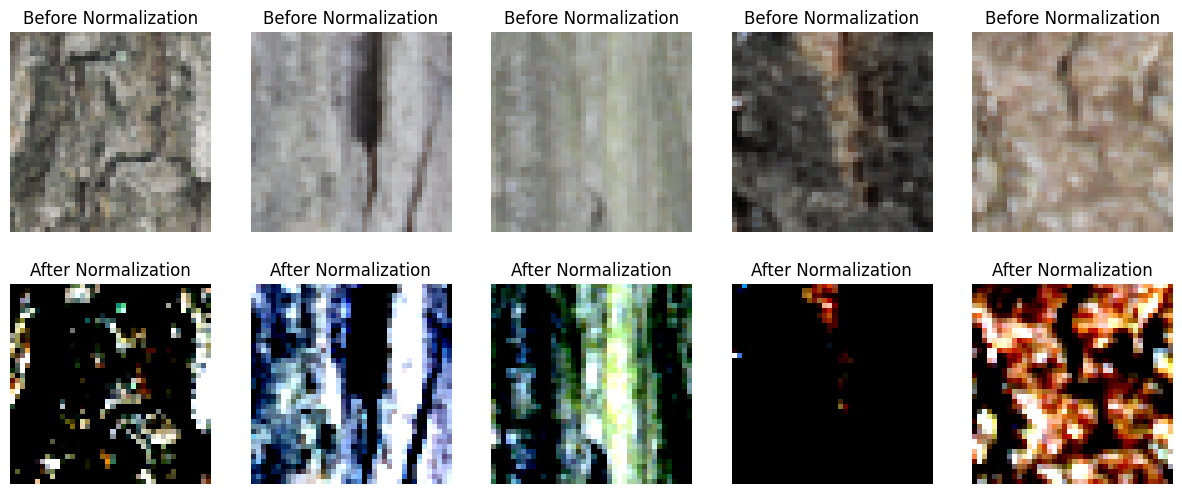

In [96]:
#vizualise some of the data to show what the pre-processing does 
f.plot_images_before_after(train_data_raw_unormalized, train_data, 5)

Training loop and evaluation function defined in functions.py
Now its time to define the model.

In [16]:
cnn_model = nn.Sequential(

            # Block One
            nn.Conv2d(3,32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block Two
            nn.Conv2d(32, 64, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),


            # Block Three
            nn.Conv2d(64, 128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
           
            # Head
            nn.Flatten(),
            nn.Linear(128*2*2, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            # Output
            nn.Linear(512, 12)          
)



In [14]:
model_base = cnn_model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_base.parameters(), lr=0.001)

f.train_model(model_base, trainloader_normalized, optimizer, criterion, 10)



Epoch [1/10], Loss: 1.8606, Accuracy: 0.3371
Epoch [2/10], Loss: 1.4704, Accuracy: 0.4819
Epoch [3/10], Loss: 1.2863, Accuracy: 0.5454
Epoch [4/10], Loss: 1.1205, Accuracy: 0.6064
Epoch [5/10], Loss: 0.9966, Accuracy: 0.6546
Epoch [6/10], Loss: 0.9218, Accuracy: 0.6793
Epoch [7/10], Loss: 0.8389, Accuracy: 0.7038
Epoch [8/10], Loss: 0.7617, Accuracy: 0.7318
Epoch [9/10], Loss: 0.7036, Accuracy: 0.7489
Epoch [10/10], Loss: 0.6551, Accuracy: 0.7682


In [15]:
test_accuracy = f.predict_and_evaluate(model_base, testloader_normalized)
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.6635


As can be seen, the base model reached an accuracy of 66% on the test data. 

Now its time for the improved model. Batchnormalization, normalization, early stopping, prelu and redsiduals will be used. Therefore the training data has to be split into validation and training. 

In [48]:

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

trainloader_normalized = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=multiprocessing.cpu_count())
valloader_normalized = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=multiprocessing.cpu_count())


A new training function is defined in the functions file, called train_model_early_stoppin.

In [103]:
cnn_model_all = nn.Sequential(

            # Block One
            nn.Conv2d(3,32, kernel_size=5),
            nn.BatchNorm2d(32),
            nn.PReLU(),
            nn.MaxPool2d(kernel_size=2),


            # Block Two
            nn.Conv2d(32, 64, kernel_size=5),
            nn.BatchNorm2d(64),
            nn.PReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block Three
            nn.Conv2d(64, 128, kernel_size=3),
            nn.BatchNorm2d(128),
            nn.PReLU(),
            nn.MaxPool2d(kernel_size=2),
           
            # Head
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.PReLU(),
            nn.Dropout(0.5),

            # Output
            nn.Linear(512, 12)
                  
)

#add residual connections
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.prelu = nn.PReLU()


        self.adjust_channels = in_channels != out_channels
        if self.adjust_channels:
            self.conv_adjust = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
            self.bn_adjust = nn.BatchNorm2d(out_channels)



    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.prelu(out)

        if self.adjust_channels:
            identity = self.conv_adjust(identity)
            identity = self.bn_adjust(identity)

        out += identity
        
        return out
    
cnn_model_resnet = nn.Sequential(

            # Block One
            ResidualBlock(3, 32, kernel_size=5),
            nn.MaxPool2d(kernel_size=2),

            # Block Two
            ResidualBlock(32, 64, kernel_size=5),
            nn.MaxPool2d(kernel_size=2),

            # Block Three
            ResidualBlock(64, 128, kernel_size=3),
            nn.MaxPool2d(kernel_size=2),

            # Head
            nn.Flatten(),
            nn.Linear(3200, 512),
            nn.PReLU(),
            nn.Dropout(0.5),

            # Output
            nn.Linear(512, 12)
            

)



Epoch [1/27], Loss: 1.6022, Accuracy: 0.4636
Validation accuracy: 0.6567
Epoch [2/27], Loss: 0.9297, Accuracy: 0.6750
Validation accuracy: 0.7352
Epoch [3/27], Loss: 0.7007, Accuracy: 0.7534
Validation accuracy: 0.7141
Epoch [4/27], Loss: 0.5883, Accuracy: 0.7911
Validation accuracy: 0.8170
Epoch [5/27], Loss: 0.4882, Accuracy: 0.8285
Validation accuracy: 0.7690
Epoch [6/27], Loss: 0.4183, Accuracy: 0.8537
Validation accuracy: 0.9173
Epoch [7/27], Loss: 0.3518, Accuracy: 0.8745
Validation accuracy: 0.8478
Epoch [8/27], Loss: 0.3113, Accuracy: 0.8901
Validation accuracy: 0.9202
Epoch [9/27], Loss: 0.2736, Accuracy: 0.9067
Validation accuracy: 0.9578
Epoch [10/27], Loss: 0.2350, Accuracy: 0.9191
Validation accuracy: 0.9143
Epoch [11/27], Loss: 0.2016, Accuracy: 0.9308
Validation accuracy: 0.9374
Early stopping at epoch 11


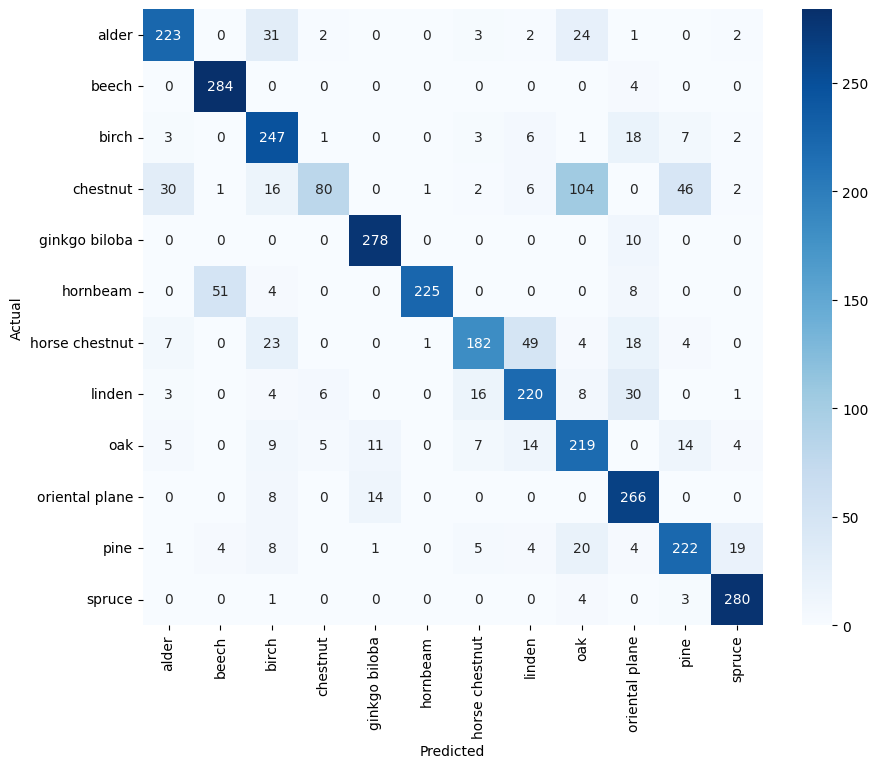

Test accuracy: 0.7888


In [35]:
model_restnet = cnn_model_resnet
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_restnet.parameters(), lr=0.001)

f.train_model_early_stopping(model_restnet, trainloader_normalized, valloader_normalized, optimizer, criterion, num_epochs=27, patience=2)

print(f"Test accuracy: {f.plot_confusion_matrix(model_restnet, testloader_normalized, 'improved model', classes):.4f}")


Now to the abliation study. Each of the improvements (batchnorm, data norm, residual blocks, activation function) missing. 

First, data norm missing: 

Epoch [1/27], Loss: 1.8115, Accuracy: 0.4063
Validation accuracy: 0.3141
Epoch [2/27], Loss: 1.0788, Accuracy: 0.6221
Validation accuracy: 0.4598
Epoch [3/27], Loss: 0.8364, Accuracy: 0.7045
Validation accuracy: 0.5990
Epoch [4/27], Loss: 0.6673, Accuracy: 0.7628
Validation accuracy: 0.5711
Epoch [5/27], Loss: 0.5652, Accuracy: 0.8057
Validation accuracy: 0.3728
Early stopping at epoch 5


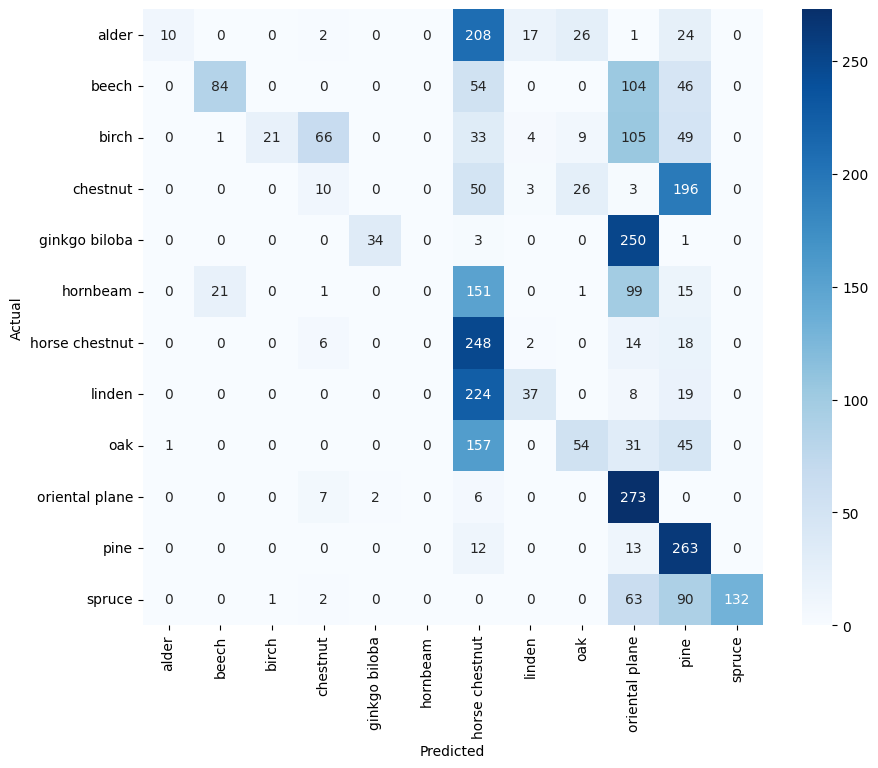

Test accuracy: 0.3374


In [39]:
#Do the same but with unnornalized data
model_restnet = cnn_model_resnet
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_restnet.parameters(), lr=0.001)

#split the data
train_size = int(0.8 * len(train_dataset_unnormalized))
val_size = len(train_dataset_unnormalized) - train_size

train_dataset_unnormalized, val_dataset_unnormalized = torch.utils.data.random_split(train_dataset_unnormalized, [train_size, val_size])

trainloader_unnormalized = DataLoader(train_dataset_unnormalized, batch_size=64, shuffle=True, num_workers=multiprocessing.cpu_count())
valloader_unnormalized = DataLoader(val_dataset_unnormalized, batch_size=64, shuffle=False, num_workers=multiprocessing.cpu_count())

f.train_model_early_stopping(model_restnet, trainloader_unnormalized, valloader_unnormalized, optimizer, criterion, num_epochs=27, patience=2)

print(f"Test accuracy: {f.plot_confusion_matrix(model_restnet, testloader_unnormalized, 'data norm missing', classes):.4f}")




Second, batchnorm missing: 

In [41]:
#add residual connections
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=kernel_size//2)
        self.prelu = nn.PReLU()


        self.adjust_channels = in_channels != out_channels
        if self.adjust_channels:
            self.conv_adjust = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)


    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.prelu(out)

        if self.adjust_channels:
            identity = self.conv_adjust(identity)

        out += identity
        
        return out
    
cnn_model_resnet = nn.Sequential(

            # Block One
            ResidualBlock(3, 32, kernel_size=5),
            nn.MaxPool2d(kernel_size=2),

            # Block Two
            ResidualBlock(32, 64, kernel_size=5),
            nn.MaxPool2d(kernel_size=2),

            # Block Three
            ResidualBlock(64, 128, kernel_size=3),
            nn.MaxPool2d(kernel_size=2),

            # Head
            nn.Flatten(),
            nn.Linear(3200, 512),
            nn.PReLU(),
            nn.Dropout(0.5),

            # Output
            nn.Linear(512, 12)
            

)



Epoch [1/27], Loss: 1.5054, Accuracy: 0.4675
Validation accuracy: 0.6372
Epoch [2/27], Loss: 0.9856, Accuracy: 0.6488
Validation accuracy: 0.7505
Epoch [3/27], Loss: 0.7612, Accuracy: 0.7303
Validation accuracy: 0.8134
Epoch [4/27], Loss: 0.5961, Accuracy: 0.7880
Validation accuracy: 0.8271
Epoch [5/27], Loss: 0.4846, Accuracy: 0.8300
Validation accuracy: 0.9137
Epoch [6/27], Loss: 0.3671, Accuracy: 0.8677
Validation accuracy: 0.9114
Epoch [7/27], Loss: 0.3176, Accuracy: 0.8891
Validation accuracy: 0.9494
Epoch [8/27], Loss: 0.2652, Accuracy: 0.9072
Validation accuracy: 0.9643
Epoch [9/27], Loss: 0.1986, Accuracy: 0.9304
Validation accuracy: 0.9617
Epoch [10/27], Loss: 0.1812, Accuracy: 0.9383
Validation accuracy: 0.9844
Epoch [11/27], Loss: 0.1506, Accuracy: 0.9490
Validation accuracy: 0.9838
Epoch [12/27], Loss: 0.1260, Accuracy: 0.9572
Validation accuracy: 0.9854
Epoch [13/27], Loss: 0.1404, Accuracy: 0.9509
Validation accuracy: 0.9783
Epoch [14/27], Loss: 0.1403, Accuracy: 0.9530
V

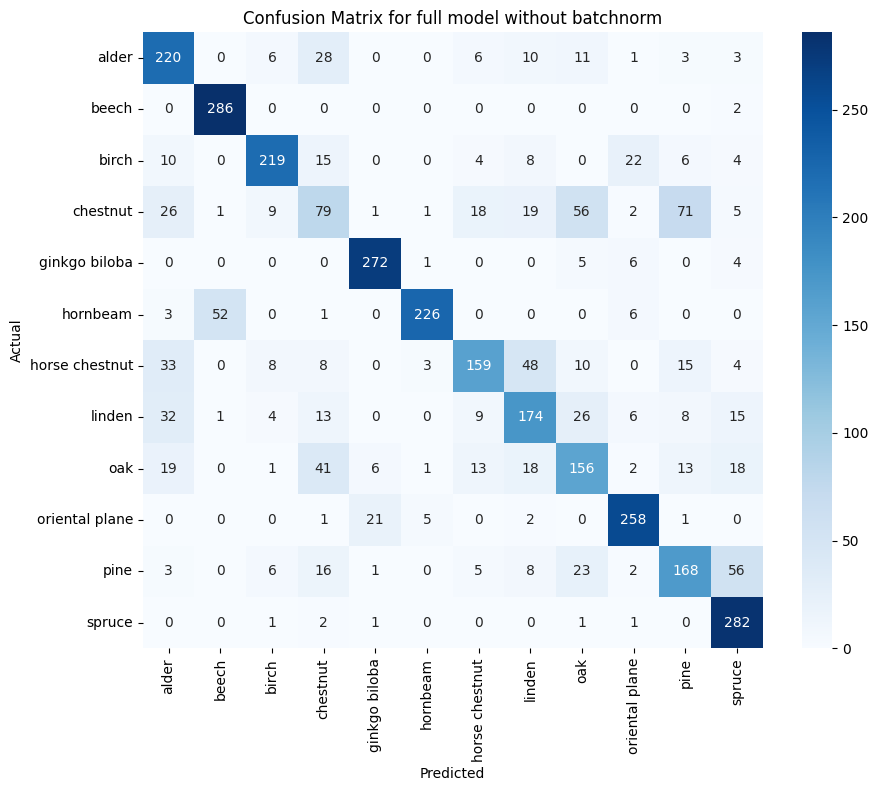

Test accuracy: 0.7231


In [42]:
model_restnet = cnn_model_resnet
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_restnet.parameters(), lr=0.001)

f.train_model_early_stopping(model_restnet, trainloader_normalized, valloader_normalized, optimizer, criterion, num_epochs=27, patience=2)

print(f"Test accuracy: {f.plot_confusion_matrix(model_restnet, testloader_normalized, 'full model without batchnorm', classes):.4f}")

Then without PRelu:

In [49]:
#add residual connections
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=False)


        self.adjust_channels = in_channels != out_channels
        if self.adjust_channels:
            self.conv_adjust = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
            self.bn_adjust = nn.BatchNorm2d(out_channels)



    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        if self.adjust_channels:
            identity = self.conv_adjust(identity)
            identity = self.bn_adjust(identity)

        out = out + identity
        
        return out
    
cnn_model_resnet = nn.Sequential(

            # Block One
            ResidualBlock(3, 32, kernel_size=5),
            nn.MaxPool2d(kernel_size=2),

            # Block Two
            ResidualBlock(32, 64, kernel_size=5),
            nn.MaxPool2d(kernel_size=2),

            # Block Three
            ResidualBlock(64, 128, kernel_size=3),
            nn.MaxPool2d(kernel_size=2),

            # Head
            nn.Flatten(),
            nn.Linear(3200, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            # Output
            nn.Linear(512, 12)
            

)



Epoch [1/27], Loss: 1.6702, Accuracy: 0.4311
Validation accuracy: 0.6029
Epoch [2/27], Loss: 1.1092, Accuracy: 0.6118
Validation accuracy: 0.7158
Epoch [3/27], Loss: 0.8975, Accuracy: 0.6869
Validation accuracy: 0.7709
Epoch [4/27], Loss: 0.7935, Accuracy: 0.7229
Validation accuracy: 0.7846
Epoch [5/27], Loss: 0.6730, Accuracy: 0.7617
Validation accuracy: 0.8378
Epoch [6/27], Loss: 0.6278, Accuracy: 0.7781
Validation accuracy: 0.8342
Epoch [7/27], Loss: 0.5526, Accuracy: 0.8060
Validation accuracy: 0.8472
Epoch [8/27], Loss: 0.5172, Accuracy: 0.8126
Validation accuracy: 0.8945
Epoch [9/27], Loss: 0.4888, Accuracy: 0.8279
Validation accuracy: 0.8832
Epoch [10/27], Loss: 0.4650, Accuracy: 0.8406
Validation accuracy: 0.8845
Early stopping at epoch 10


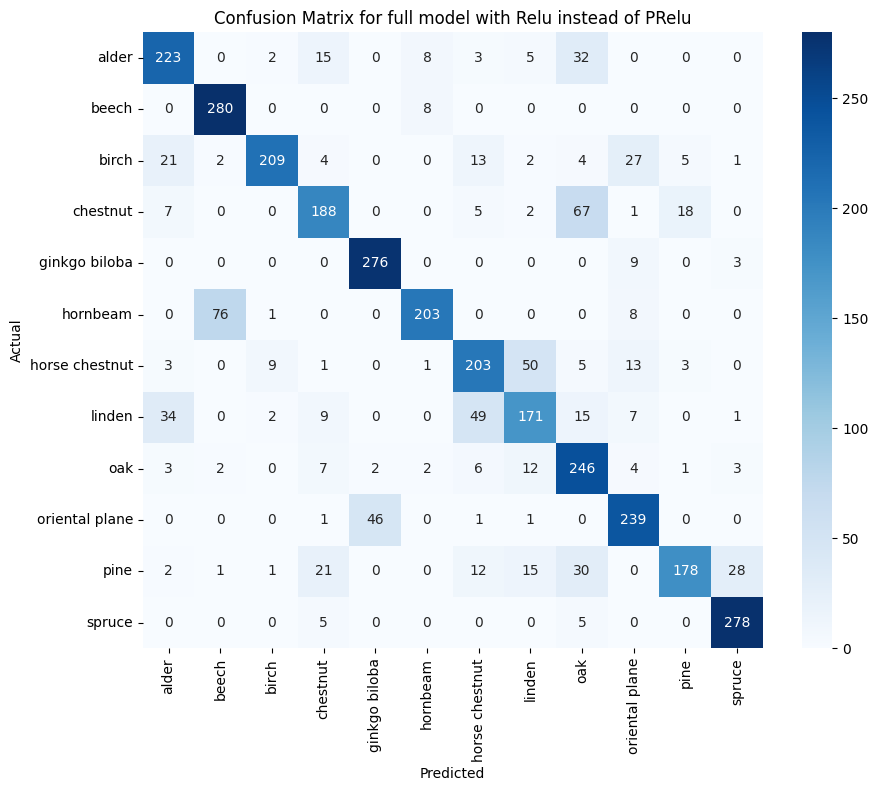

Test accuracy: 0.7795


In [50]:
model_restnet = cnn_model_resnet
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_restnet.parameters(), lr=0.001)

f.train_model_early_stopping(model_restnet, trainloader_normalized, valloader_normalized, optimizer, criterion, num_epochs=27, patience=2)

print(f"Test accuracy: {f.plot_confusion_matrix(model_restnet, testloader_normalized, 'full model with Relu instead of PRelu', classes):.4f}")

Without early stopping

In [104]:
model_without_e_s = cnn_model_resnet
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_without_e_s.parameters(), lr=0.001)

f.train_model(model_without_e_s, trainloader_normalized, optimizer, criterion, 20)



Epoch [1/20], Loss: 1.6499, Accuracy: 0.4516
Epoch [2/20], Loss: 0.9177, Accuracy: 0.6787
Epoch [3/20], Loss: 0.7288, Accuracy: 0.7425
Epoch [4/20], Loss: 0.5826, Accuracy: 0.7938
Epoch [5/20], Loss: 0.5019, Accuracy: 0.8224
Epoch [6/20], Loss: 0.4291, Accuracy: 0.8490
Epoch [7/20], Loss: 0.3651, Accuracy: 0.8712
Epoch [8/20], Loss: 0.3202, Accuracy: 0.8853
Epoch [9/20], Loss: 0.2786, Accuracy: 0.9060
Epoch [10/20], Loss: 0.2399, Accuracy: 0.9147
Epoch [11/20], Loss: 0.2326, Accuracy: 0.9188
Epoch [12/20], Loss: 0.1976, Accuracy: 0.9308
Epoch [13/20], Loss: 0.1888, Accuracy: 0.9367
Epoch [14/20], Loss: 0.1515, Accuracy: 0.9461
Epoch [15/20], Loss: 0.1580, Accuracy: 0.9456
Epoch [16/20], Loss: 0.1345, Accuracy: 0.9529
Epoch [17/20], Loss: 0.1553, Accuracy: 0.9488
Epoch [18/20], Loss: 0.1465, Accuracy: 0.9520
Epoch [19/20], Loss: 0.1272, Accuracy: 0.9579
Epoch [20/20], Loss: 0.1014, Accuracy: 0.9672


TypeError: plot_confusion_matrix() missing 1 required positional argument: 'title'

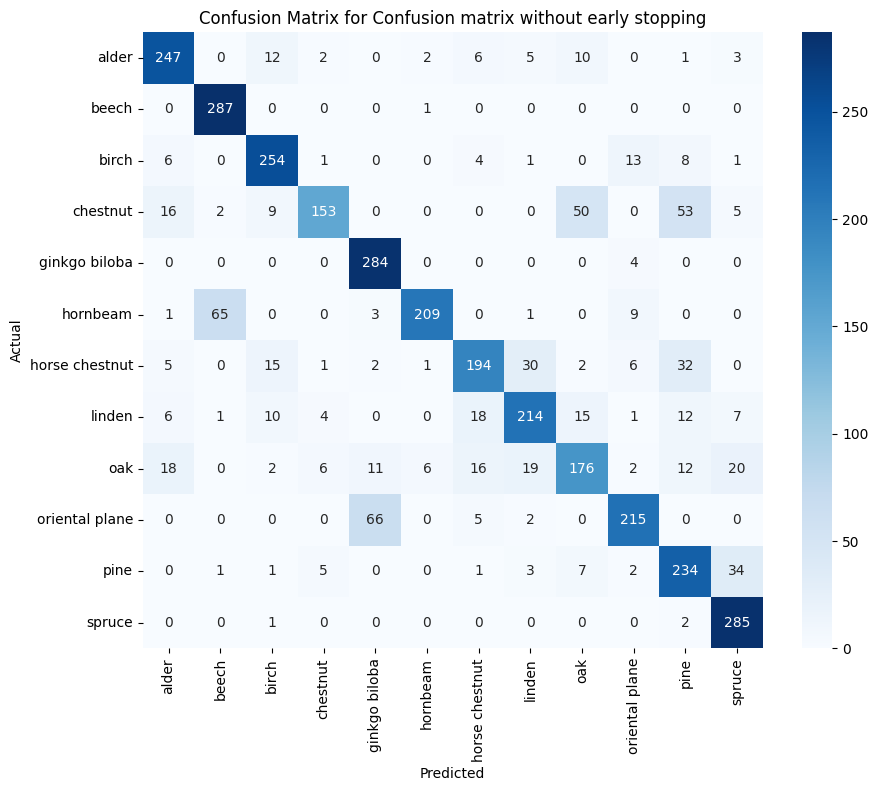

Test accuracy: 0.7963


In [109]:
print(f"Test accuracy: {f.plot_confusion_matrix(model_without_e_s, testloader_normalized, 'Confusion matrix without early stopping', classes):.4f}")

And finally the full model without the residual connections: 

In [52]:


class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.prelu = nn.PReLU()



    def forward(self, x):

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.prelu(out)

        
        return out
    
cnn_model_resnet = nn.Sequential(

            # Block One
            ResidualBlock(3, 32, kernel_size=5),
            nn.MaxPool2d(kernel_size=2),

            # Block Two
            ResidualBlock(32, 64, kernel_size=5),
            nn.MaxPool2d(kernel_size=2),

            # Block Three
            ResidualBlock(64, 128, kernel_size=3),
            nn.MaxPool2d(kernel_size=2),

            # Head
            nn.Flatten(),
            nn.Linear(3200, 512),
            nn.PReLU(),
            nn.Dropout(0.5),

            # Output
            nn.Linear(512, 12)
            

)





Epoch [1/27], Loss: 1.6911, Accuracy: 0.4203
Validation accuracy: 0.5480
Epoch [2/27], Loss: 1.1086, Accuracy: 0.6161
Validation accuracy: 0.6541
Epoch [3/27], Loss: 0.8792, Accuracy: 0.6932
Validation accuracy: 0.7674
Epoch [4/27], Loss: 0.7429, Accuracy: 0.7430
Validation accuracy: 0.7586
Epoch [5/27], Loss: 0.6355, Accuracy: 0.7770
Validation accuracy: 0.7631
Early stopping at epoch 5


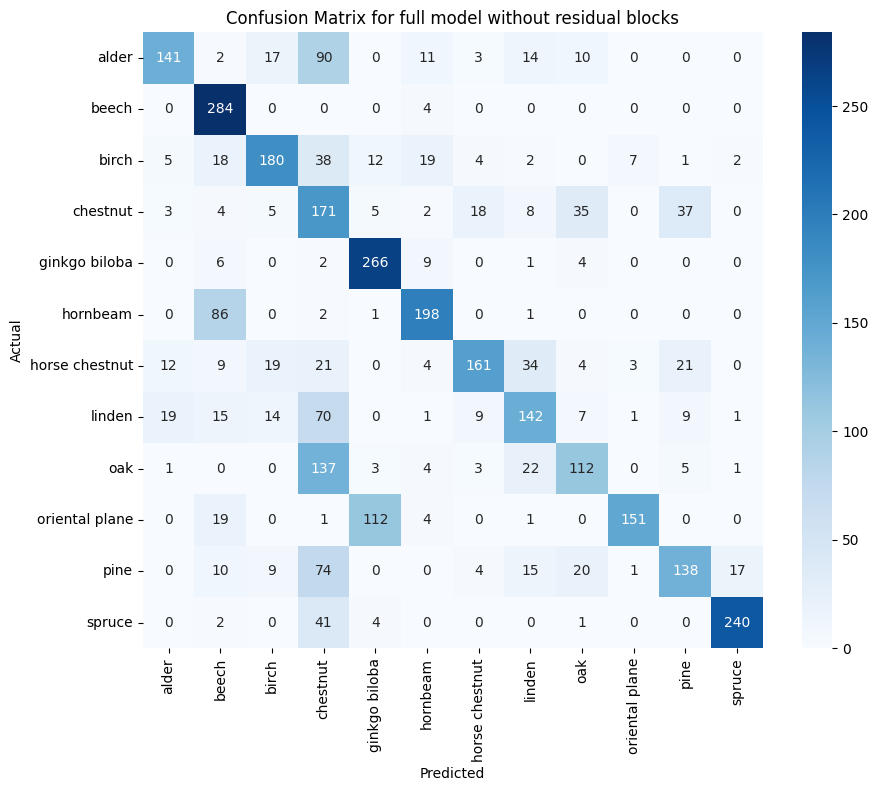

Test accuracy: 0.6319


In [53]:
model_restnet = cnn_model_resnet
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_restnet.parameters(), lr=0.001)

f.train_model_early_stopping(model_restnet, trainloader_normalized, valloader_normalized, optimizer, criterion, num_epochs=27, patience=2)

print(f"Test accuracy: {f.plot_confusion_matrix(model_restnet, testloader_normalized, 'full model without residual blocks', classes):.4f}")

Display some incorrect and correctly classifed images.
I had to retrain the improved model since it had been overwritten

In [49]:
model_restnet = cnn_model_resnet
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_restnet.parameters(), lr=0.001)

f.train_model_early_stopping(model_restnet, trainloader_normalized, valloader_normalized, optimizer, criterion, num_epochs=27, patience=2)



Epoch [1/27], Loss: 1.7780, Accuracy: 0.4181
Validation accuracy: 0.6275
Epoch [2/27], Loss: 1.0133, Accuracy: 0.6459
Validation accuracy: 0.7229
Epoch [3/27], Loss: 0.7682, Accuracy: 0.7289
Validation accuracy: 0.7291
Epoch [4/27], Loss: 0.6490, Accuracy: 0.7710
Validation accuracy: 0.6548
Epoch [5/27], Loss: 0.5574, Accuracy: 0.8055
Validation accuracy: 0.8073
Epoch [6/27], Loss: 0.4816, Accuracy: 0.8336
Validation accuracy: 0.7829
Epoch [7/27], Loss: 0.4251, Accuracy: 0.8525
Validation accuracy: 0.7664
Early stopping at epoch 7


TypeError: plot_confusion_matrix() missing 1 required positional argument: 'title'

In [88]:
subset_size = 15

# Get a random subset of the test dataset
test_subset, original_indicies = f.get_random_test_subset(test_dataset, subset_size)

# Create a DataLoader for the subset
testloader_subset = DataLoader(test_subset, batch_size=subset_size, shuffle=False, num_workers=multiprocessing.cpu_count())


In [82]:
print(original_indicies)

[319, 843, 856, 2441, 824, 2251, 283, 567, 1748, 2352]


In [90]:
print(f.predict_and_evaluate(model_restnet, testloader_subset))
predictions, labels = f.get_preds(model_restnet, testloader_subset)

0.6666666666666666


In [91]:
for images, labels in testloader_subset:
    break 
#Just to get easy access to the images and labels

In [77]:
print(images.shape[0])

10


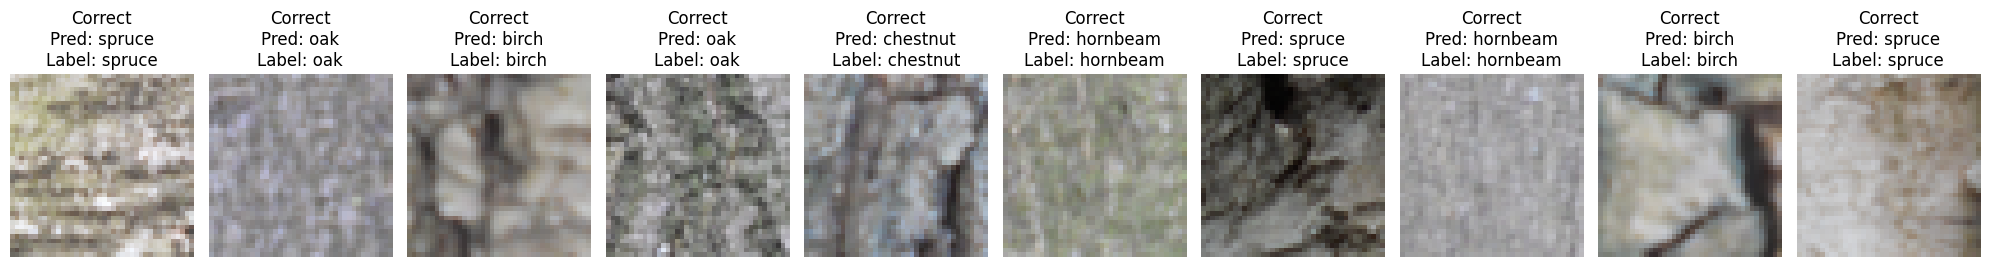

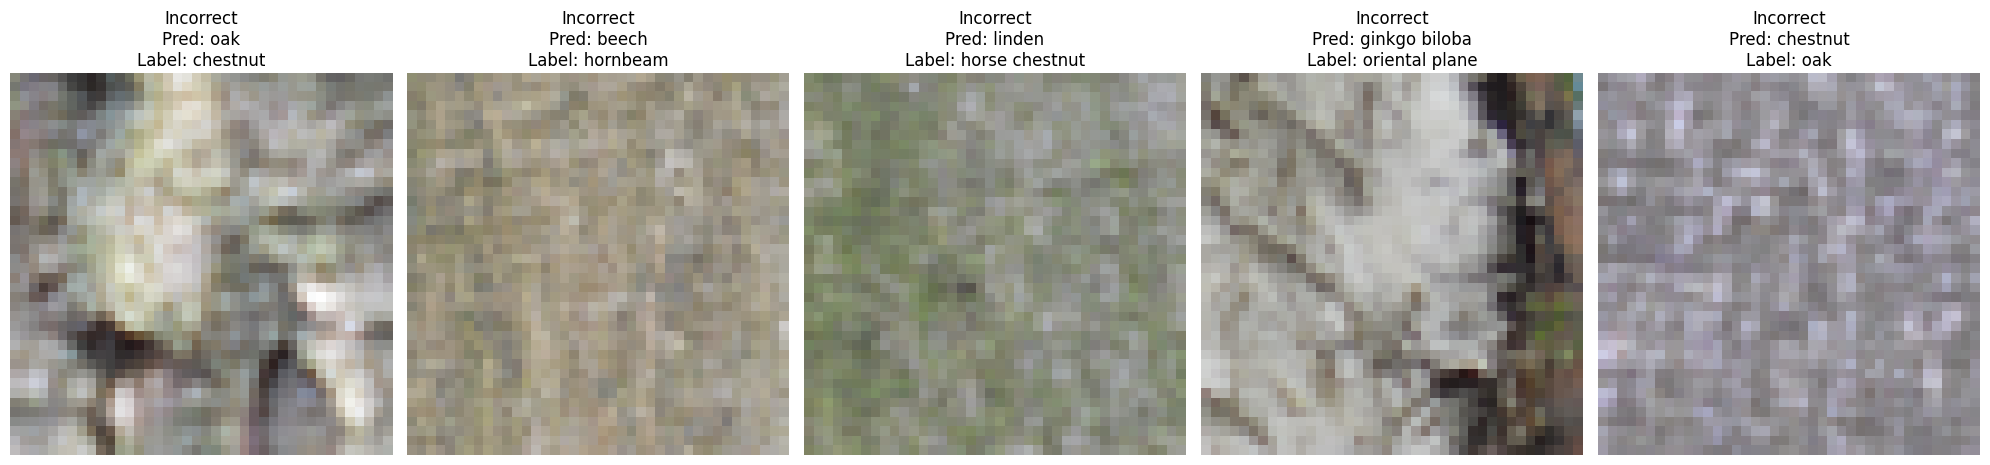

In [92]:
predictions = np.array(predictions)
labels = np.array(labels)

# Indices for correct and incorrect predictions
correct_indices = [i for i in range(len(predictions)) if predictions[i] == labels[i]]
incorrect_indices = [i for i in range(len(predictions)) if predictions[i] != labels[i]]

# Plotting correct predictions
fig_correct, axs_correct = plt.subplots(1, len(correct_indices), figsize=(20, 6))

for idx, i in enumerate(correct_indices):
    img = train_data_raw_unormalized[original_indicies[i]].transpose(1, 2, 0)
    axs_correct[idx].imshow(img)
    axs_correct[idx].set_title(f"Correct\nPred: {classes[predictions[i]]}\nLabel: {classes[labels[i]]}")
    axs_correct[idx].axis('off')

plt.tight_layout()
plt.show()

# Plotting incorrect predictions
fig_incorrect, axs_incorrect = plt.subplots(1, len(incorrect_indices), figsize=(20, 6))

for idx, i in enumerate(incorrect_indices):
    img = train_data_raw_unormalized[original_indicies[i]].transpose(1, 2, 0)
    axs_incorrect[idx].imshow(img)
    axs_incorrect[idx].set_title(f"Incorrect\nPred: {classes[predictions[i]]}\nLabel: {classes[labels[i]]}")
    axs_incorrect[idx].axis('off')

plt.tight_layout()
plt.show()


Advanced part: first load the data

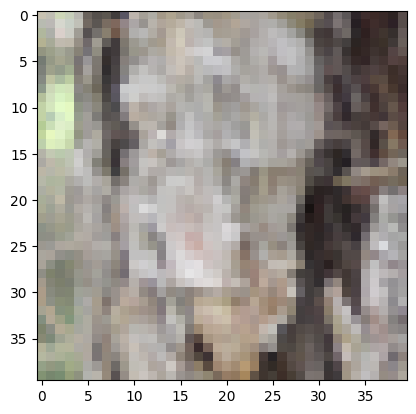

In [23]:
data_advanced_part = loadmat('matlab/data_a.mat')

data_advanced = data_advanced_part['data_advanced'][0][0]
labels_advanced = data_advanced_part['data_advanced'][0][1].squeeze()
labels_advanced = [l[0] for l in labels_advanced]
labels_advanced = [1 if l == 'id' else 0 for l in labels_advanced]


# The training data has shape (40, 40, 3, 2000), Reshape to (samples, channels, height, widht) = (2000, 40, 40, 3)
data_advanced = np.transpose(data_advanced, (3, 2, 0, 1))


#display one image
plt.imshow(data_advanced[0].transpose(1, 2, 0))
plt.show()


labels_advanced = torch.tensor(labels_advanced, dtype=torch.long)
data_advanced = torch.tensor(data_advanced, dtype=torch.float32)


#normalize the data
data_advanced = (data_advanced - mean[None, :, None, None]) / std[None, :, None, None]

advanced_dataset = TensorDataset(data_advanced, labels_advanced)
advanced_loader = DataLoader(advanced_dataset, batch_size=32, shuffle=False, num_workers=multiprocessing.cpu_count())



In [18]:
#Create a new model where its possible to get the features from the last layer
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.prelu = nn.PReLU()


        self.adjust_channels = in_channels != out_channels
        if self.adjust_channels:
            self.conv_adjust = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
            self.bn_adjust = nn.BatchNorm2d(out_channels)



    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.prelu(out)

        if self.adjust_channels:
            identity = self.conv_adjust(identity)
            identity = self.bn_adjust(identity)

        out += identity
        
        return out
    
class CNNWithFeatures(nn.Module):
    def __init__(self):
        super(CNNWithFeatures, self).__init__()

        self.features = nn.Sequential(

            # Block One
            ResidualBlock(3, 32, kernel_size=5),
            nn.MaxPool2d(kernel_size=2),

            # Block Two
            ResidualBlock(32, 64, kernel_size=5),
            nn.MaxPool2d(kernel_size=2),

            # Block Three
            ResidualBlock(64, 128, kernel_size=3),
            nn.MaxPool2d(kernel_size=2),
        )

        self.head = nn.Sequential(
            # Head
            nn.Flatten(),
            nn.Linear(3200, 512),
            nn.PReLU(),
            nn.Dropout(0.5),

            # Output
            nn.Linear(512, 12)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x

    def get_features(self, x):
        return self.features(x)

In [19]:
model_with_features = CNNWithFeatures()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_with_features.parameters(), lr=0.001)

train_model_early_stopping(model_with_features, trainloader_normalized, valloader_normalized, optimizer, criterion, num_epochs=27, patience=2)


Epoch [1/27], Loss: 1.6709, Accuracy: 0.4474
Validation accuracy: 0.5581
Epoch [2/27], Loss: 0.9611, Accuracy: 0.6610
Validation accuracy: 0.6486
Epoch [3/27], Loss: 0.7601, Accuracy: 0.7341
Validation accuracy: 0.7505
Epoch [4/27], Loss: 0.6195, Accuracy: 0.7808
Validation accuracy: 0.8199
Epoch [5/27], Loss: 0.5376, Accuracy: 0.8070
Validation accuracy: 0.8189
Epoch [6/27], Loss: 0.4568, Accuracy: 0.8415
Validation accuracy: 0.8423
Epoch [7/27], Loss: 0.3844, Accuracy: 0.8674
Validation accuracy: 0.7476
Epoch [8/27], Loss: 0.3562, Accuracy: 0.8754
Validation accuracy: 0.8371
Early stopping at epoch 8


First I tried to extract all feature value and plot a distribution of this. This histogram did not separate the data very nicely. 

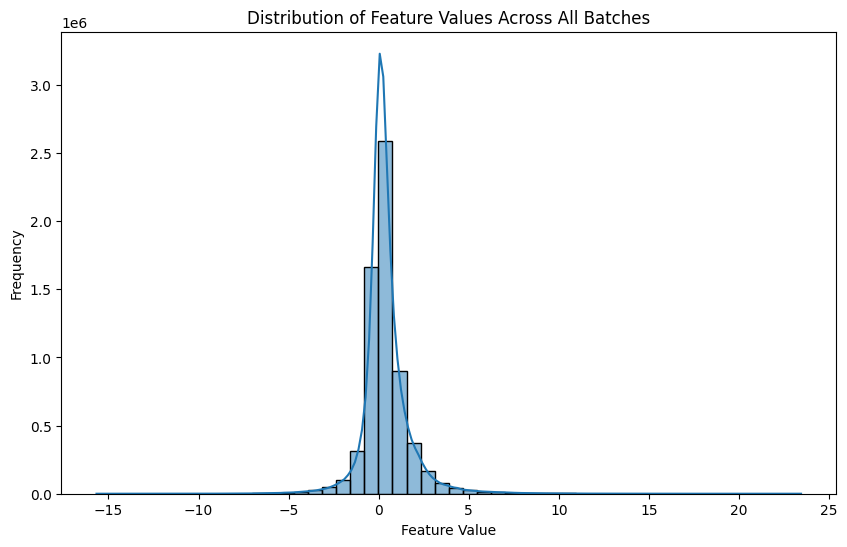

In [146]:
import seaborn as sns
features = []
all_labels = []

model_with_features.eval()
with torch.no_grad():
    for inputs, labels in advanced_loader:
        batch_features = model_with_features.get_features(inputs)
        features.append(batch_features)
        
        all_labels.append(labels)

features = torch.cat(features, dim=0)
flattened_features = features.view(-1)
flattened_features_np = flattened_features.numpy()

plt.figure(figsize=(10, 6))
sns.histplot(flattened_features_np, bins=50, kde=True)
plt.title("Distribution of Feature Values Across All Batches")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.show()



Instead, I want to find the most impotrant features. Since there are 128 different features, I can not mamually plot and inspect each one. Instead I use a principal component analyzer. 

(2000, 128)
Top 5 feature indices: [ 68  89 100  60 127  25  11   6  90  81]
Corresponding importances: [0.11542714 0.11584584 0.11587506 0.11594778 0.11598047 0.11646698
 0.1170712  0.11982061 0.1208046  0.12091492]


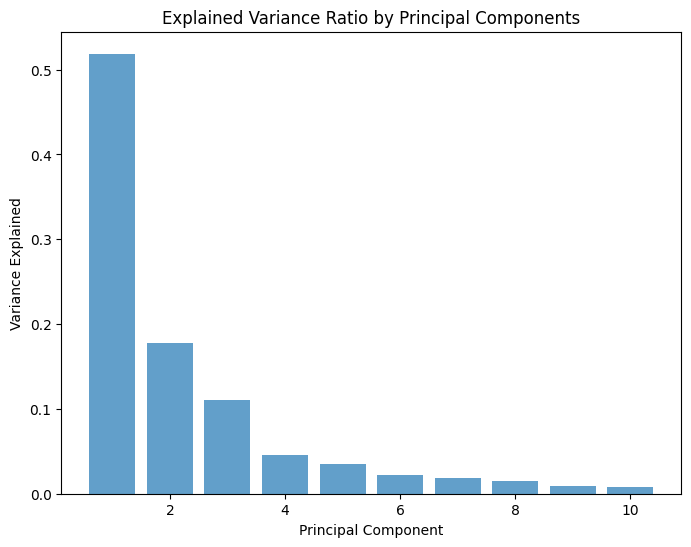

In [117]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


feature_means = features.mean(dim=[2, 3])

feature_means_np = feature_means.numpy()
print(feature_means_np.shape)   


mean = np.mean(feature_means_np, axis=0)
std = np.std(feature_means_np, axis=0)
standardized_features = (feature_means_np - mean) / std


pca = PCA(n_components=10) 
pca.fit(standardized_features)

loadings = pca.components_.T 


importance = np.abs(loadings[:, 0])
top_feature_indices = np.argsort(importance)[-10:] 

print(f"Top 10 feature indices: {top_feature_indices}")
print(f"Corresponding importances: {importance[top_feature_indices]}")

plt.figure(figsize=(8, 6))
plt.bar(range(1, 11), pca.explained_variance_ratio_[:10], alpha=0.7, align='center')
plt.xlabel('Principal Component')
plt.ylabel('Variance')
plt.title('Variance Ratio by Principal Components')
plt.show()

I can see in the plot above that feature 68 has the highest variance, but this does not neccessarily mean that this feature is the best choice for separating ID and OOD. I want to plot the distributions for these features to see if there are any obvious separations between ID and OOD distributions.

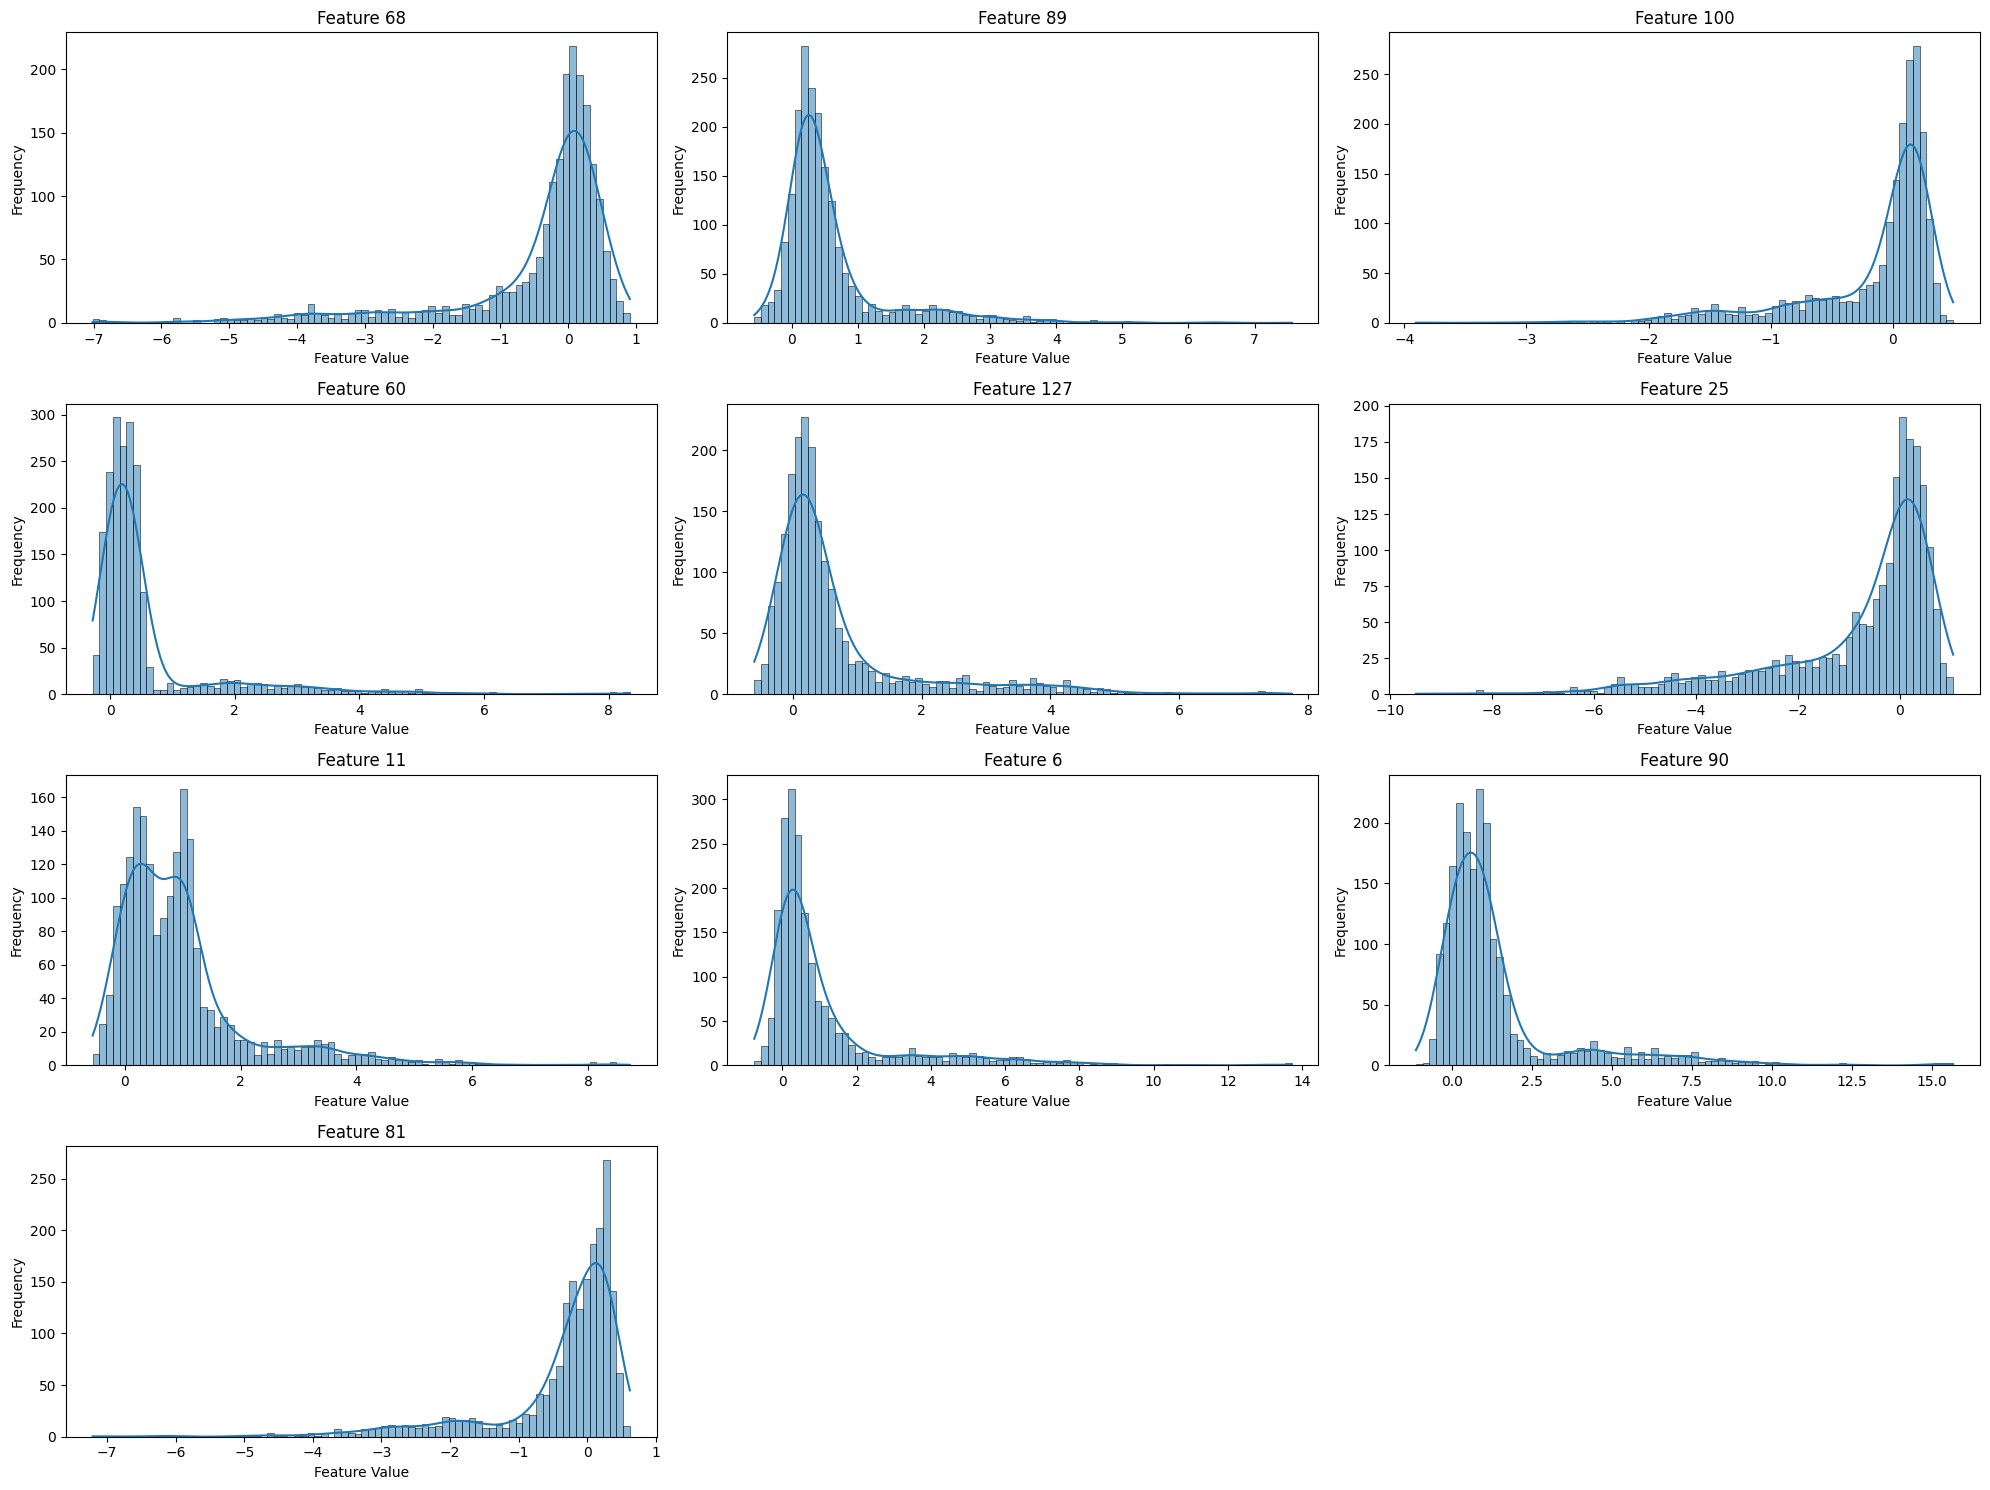

In [120]:
plt.figure(figsize=(20, 15))
for i, feature_index in enumerate(top_feature_indices):
    plt.subplot(4, 3, i + 1)
    sns.histplot(feature_means_np[:, feature_index], kde=True, bins=80)
    plt.title(f'Feature {feature_index}')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Many of the features seem to have been chosen because they have a very long tail. The features I can guess might be a good choice are the following: 
- feature 11 with threshold 0.5
- feature 90 with threshold 0.6
- feature 81 with threshold -0.1 

In [155]:
all_labels_np = np.array(torch.cat(all_labels, dim=0))


best_feature_indices = [11, 90, 81]  
corresponding_thresholds = [0.5, 0.6, -0.1]

for feature_index, threshold in zip(best_feature_indices, corresponding_thresholds):
    feature_values = feature_means_np[:, feature_index]
    predictions = (feature_values < threshold).astype(int)

    accuracy = np.mean(predictions == all_labels_np)
    print(f"Accuracy for feature {feature_index} with threshold {threshold}: {accuracy:.4f}")
   

Accuracy for feature 11 with threshold 0.5: 0.9115
Accuracy for feature 90 with threshold 0.6: 0.9100
Accuracy for feature 81 with threshold -0.1: 0.0815


I can see that the last feature separates the classes in the opposite direction than the others, so the accuracy is in reality 1-0.0815 = 0.92.
Since feature 11 and 90 had their threshold as similar values, I tried to add these features toghether to hopefully get more robust predictions that are less sensitive to random incorrect values. 

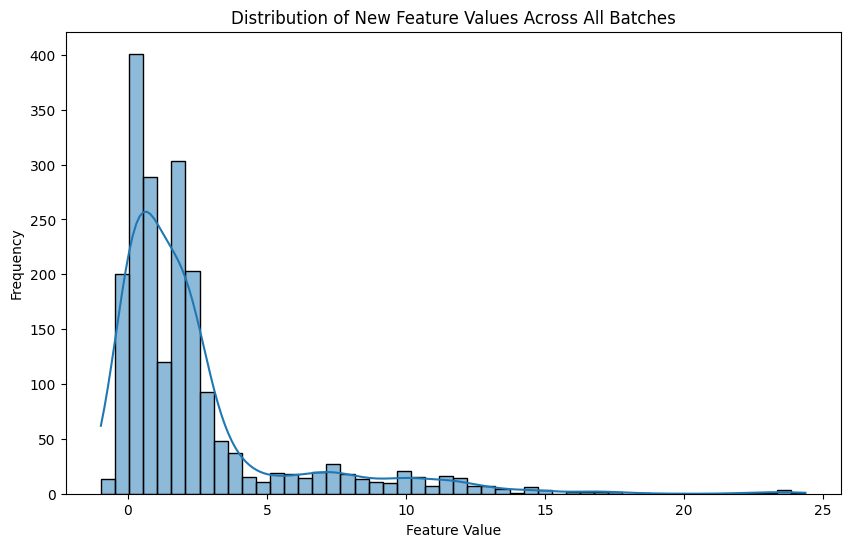

In [191]:
#add features 11 and 90 together
feature_means_np = feature_means.numpy()
new_feature = feature_means_np[:, 11] + feature_means_np[:, 90] 

#plot the new feature
plt.figure(figsize=(10, 6))
sns.histplot(new_feature, bins=50, kde=True)
plt.title("Distribution of New Feature Values Across All Batches")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.show()


With this new plot, the threshold for the joined feature seems to be around 1.5. 

Feature index: combined 11 and 90
Accuracy: 0.976
Confusion Matrix:
[[975  25]
 [ 23 977]]


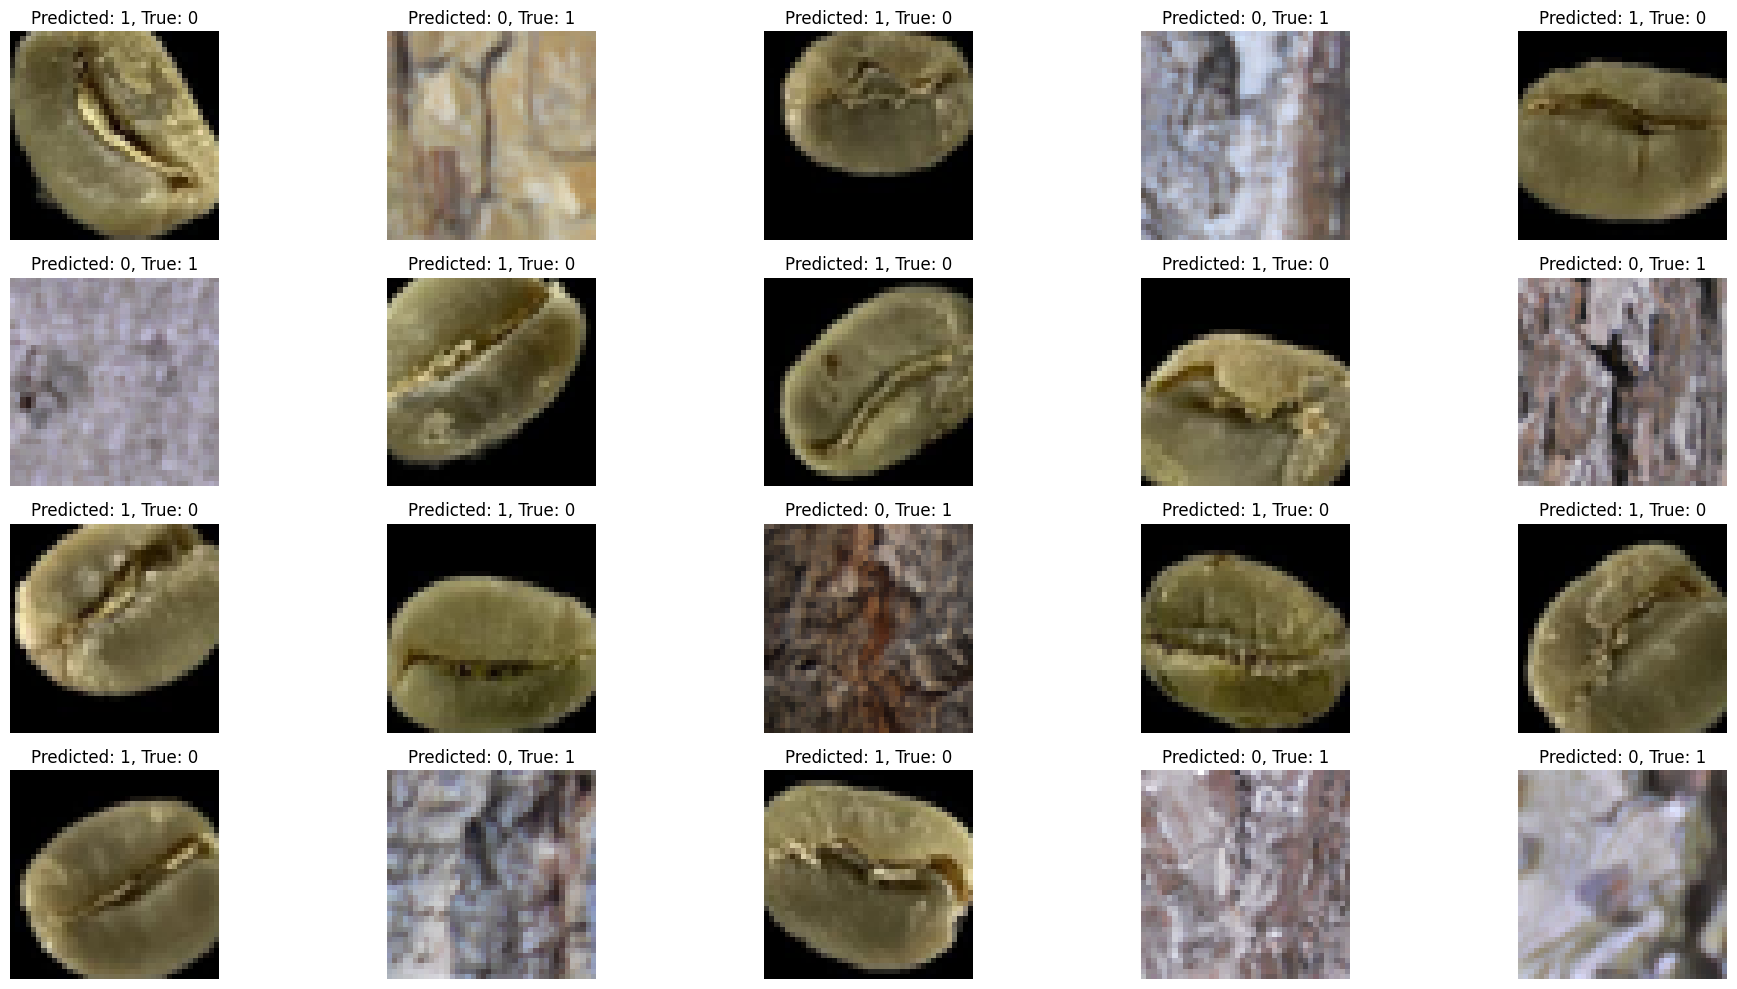

In [202]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


threshold = 1.5

predictions = (new_feature < threshold).astype(int)


accuracy = accuracy_score(all_labels_np, predictions)
report = classification_report(all_labels_np, predictions)
conf_matrix = confusion_matrix(all_labels_np, predictions)

print(f'Feature index: combined 11 and 90')
print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)

misclassified_indices = np.where(predictions != all_labels_np)[0]

data_advanced_part = loadmat('matlab/data_a.mat')

data_advanced = data_advanced_part['data_advanced'][0][0]



# The training data has shape (40, 40, 3, 2000), Reshape to (samples, channels, height, widht) = (2000, 40, 40, 3)
data_advanced = np.transpose(data_advanced, (3, 2, 0, 1))
#plot the misclassified images
import matplotlib.pyplot as plt


plt.figure(figsize=(20, 10))

#choose 5 images to display
for i, idx in enumerate(misclassified_indices[:20]):
    plt.subplot(4, 5, i + 1)
    plt.imshow(data_advanced[idx].transpose(1, 2, 0))
    plt.title(f"Predicted: {predictions[idx]}, True: {all_labels_np[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


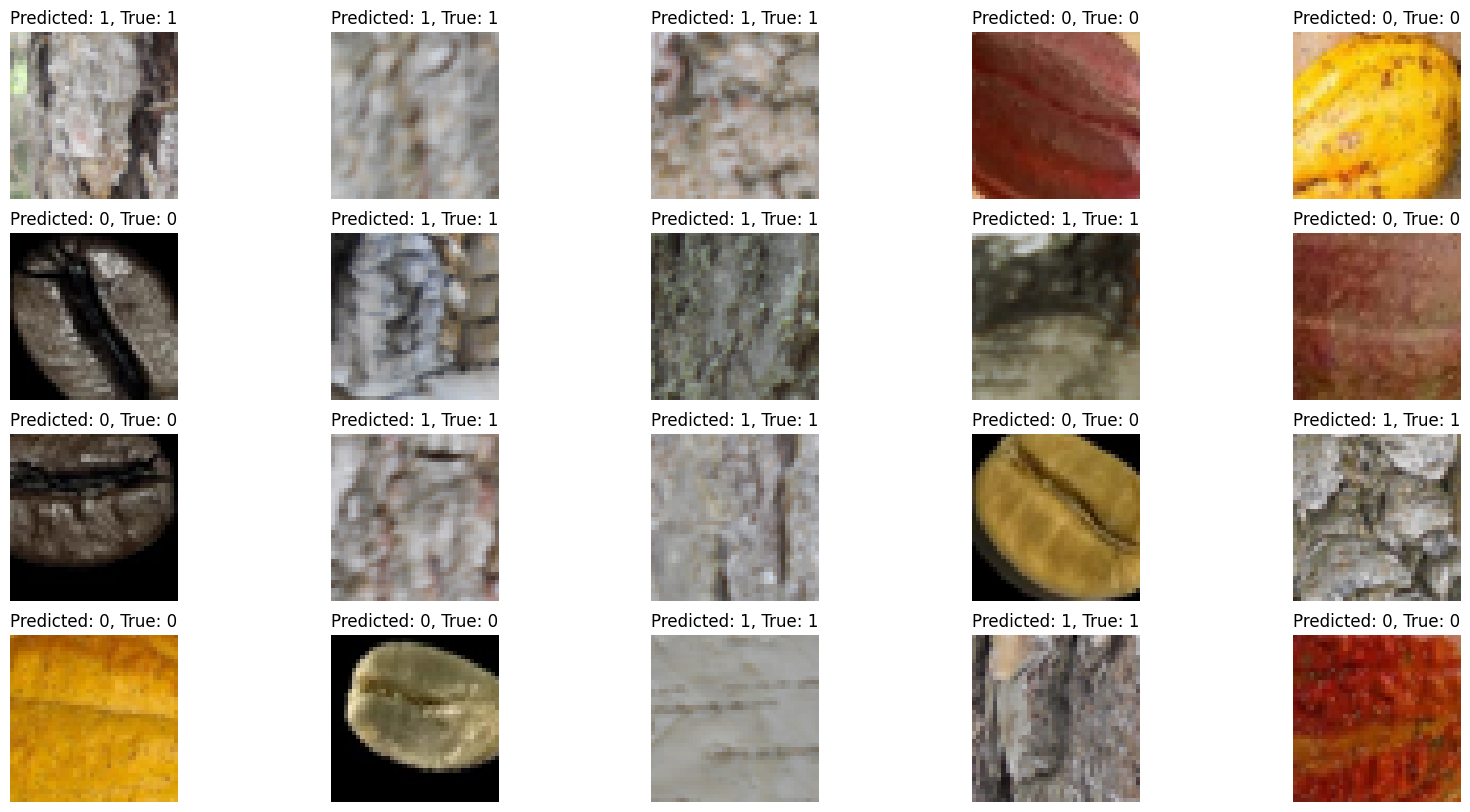

In [203]:
#print a few correctly classified images from each class
correct_indices = np.where(predictions == all_labels_np)[0]

plt.figure(figsize=(20, 10))

#choose 5 images to display
for i, idx in enumerate(correct_indices[:20]):
    plt.subplot(4, 5, i + 1)
    plt.imshow(data_advanced[idx].transpose(1, 2, 0))
    plt.title(f"Predicted: {predictions[idx]}, True: {all_labels_np[idx]}")
    plt.axis('off')

Since the distributions have long tails, I want to see if I can find any better features by removing outliers and values that are not as frequent as other. This could help me find features that have more compact but still separate distributions. 

In [131]:
from sklearn.decomposition import PCA
import scipy.stats as stats
from sklearn.preprocessing import RobustScaler

# Apply Winsorization to remove outliers
winsorized_features = stats.mstats.winsorize(feature_means_np, limits=[0.05, 0.05])

pca = PCA(n_components=10) 
principal_components = pca.fit_transform(winsorized_features)

loadings = pca.components_.T 


importance = np.abs(loadings[:, 0])
top_feature_indices = np.argsort(importance)[-10:] 

print(f"Top 10 feature indices: {top_feature_indices}")
print(f"Corresponding importances: {importance[top_feature_indices]}")


Top 10 feature indices: [119  48  33  19  42  90 107  91  85  72]
Corresponding importances: [0.14850844 0.14882848 0.14971489 0.15026067 0.15444258 0.1582267
 0.16029714 0.16261514 0.16276981 0.16896507]


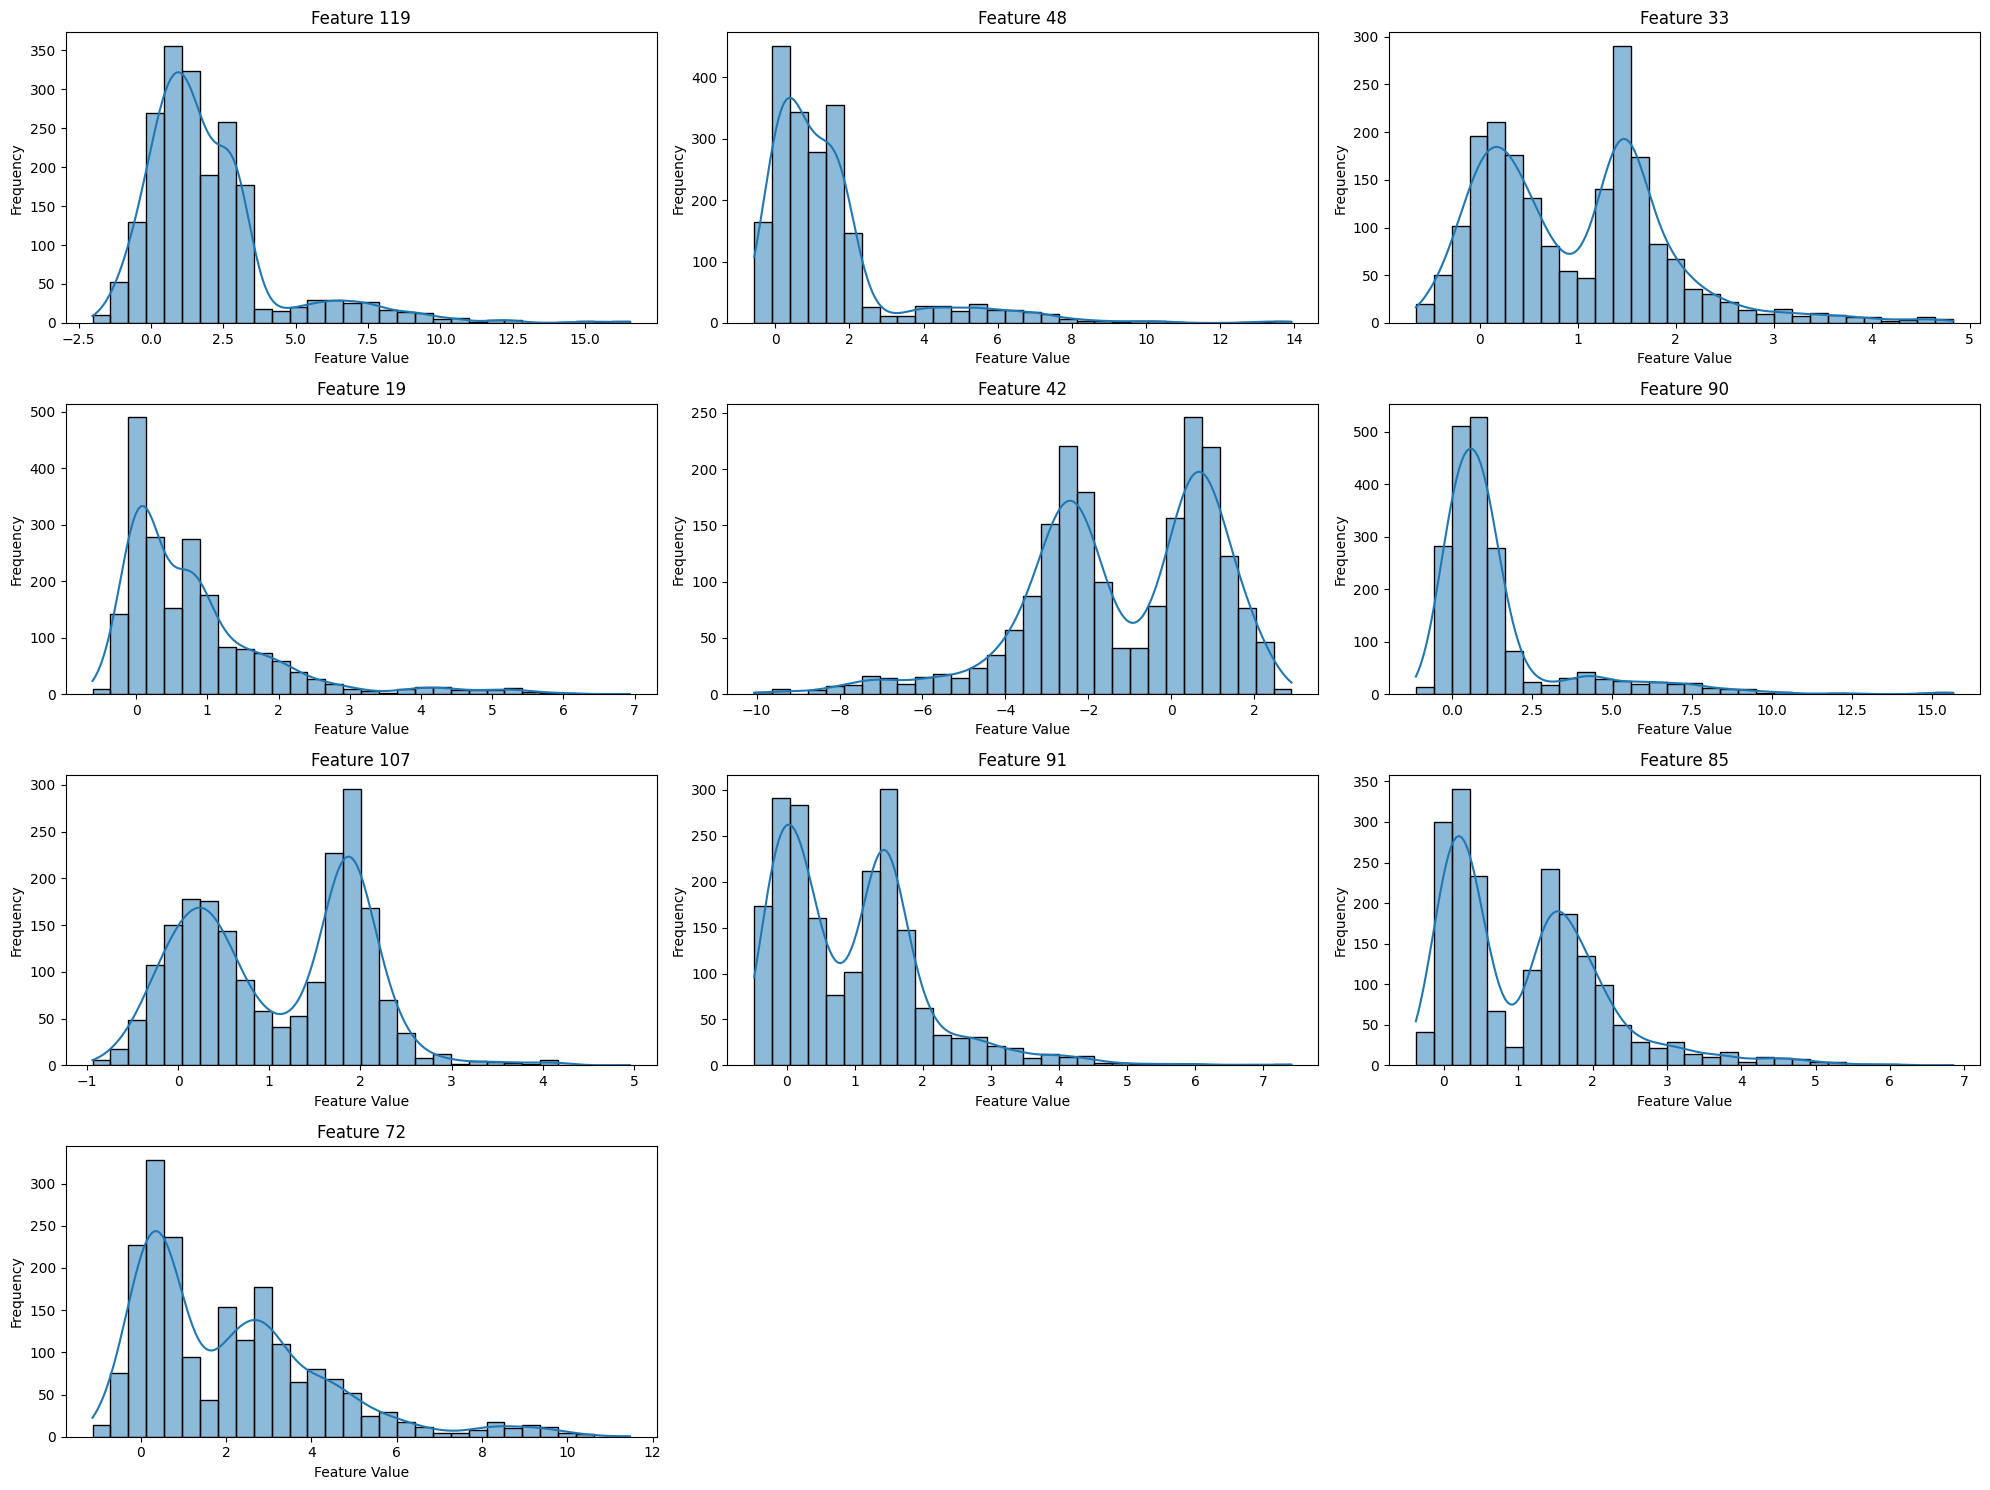

In [161]:
plt.figure(figsize=(20, 15))
for i, feature_index in enumerate(top_feature_indices):
    plt.subplot(4, 3, i + 1)
    sns.histplot(feature_means_np[:, feature_index], kde=True, bins=30)
    plt.title(f'Feature {feature_index}')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

To be able to chose more exact positions for the thresholds, I also plot the distirubtion for the outlier free data and use both these plots

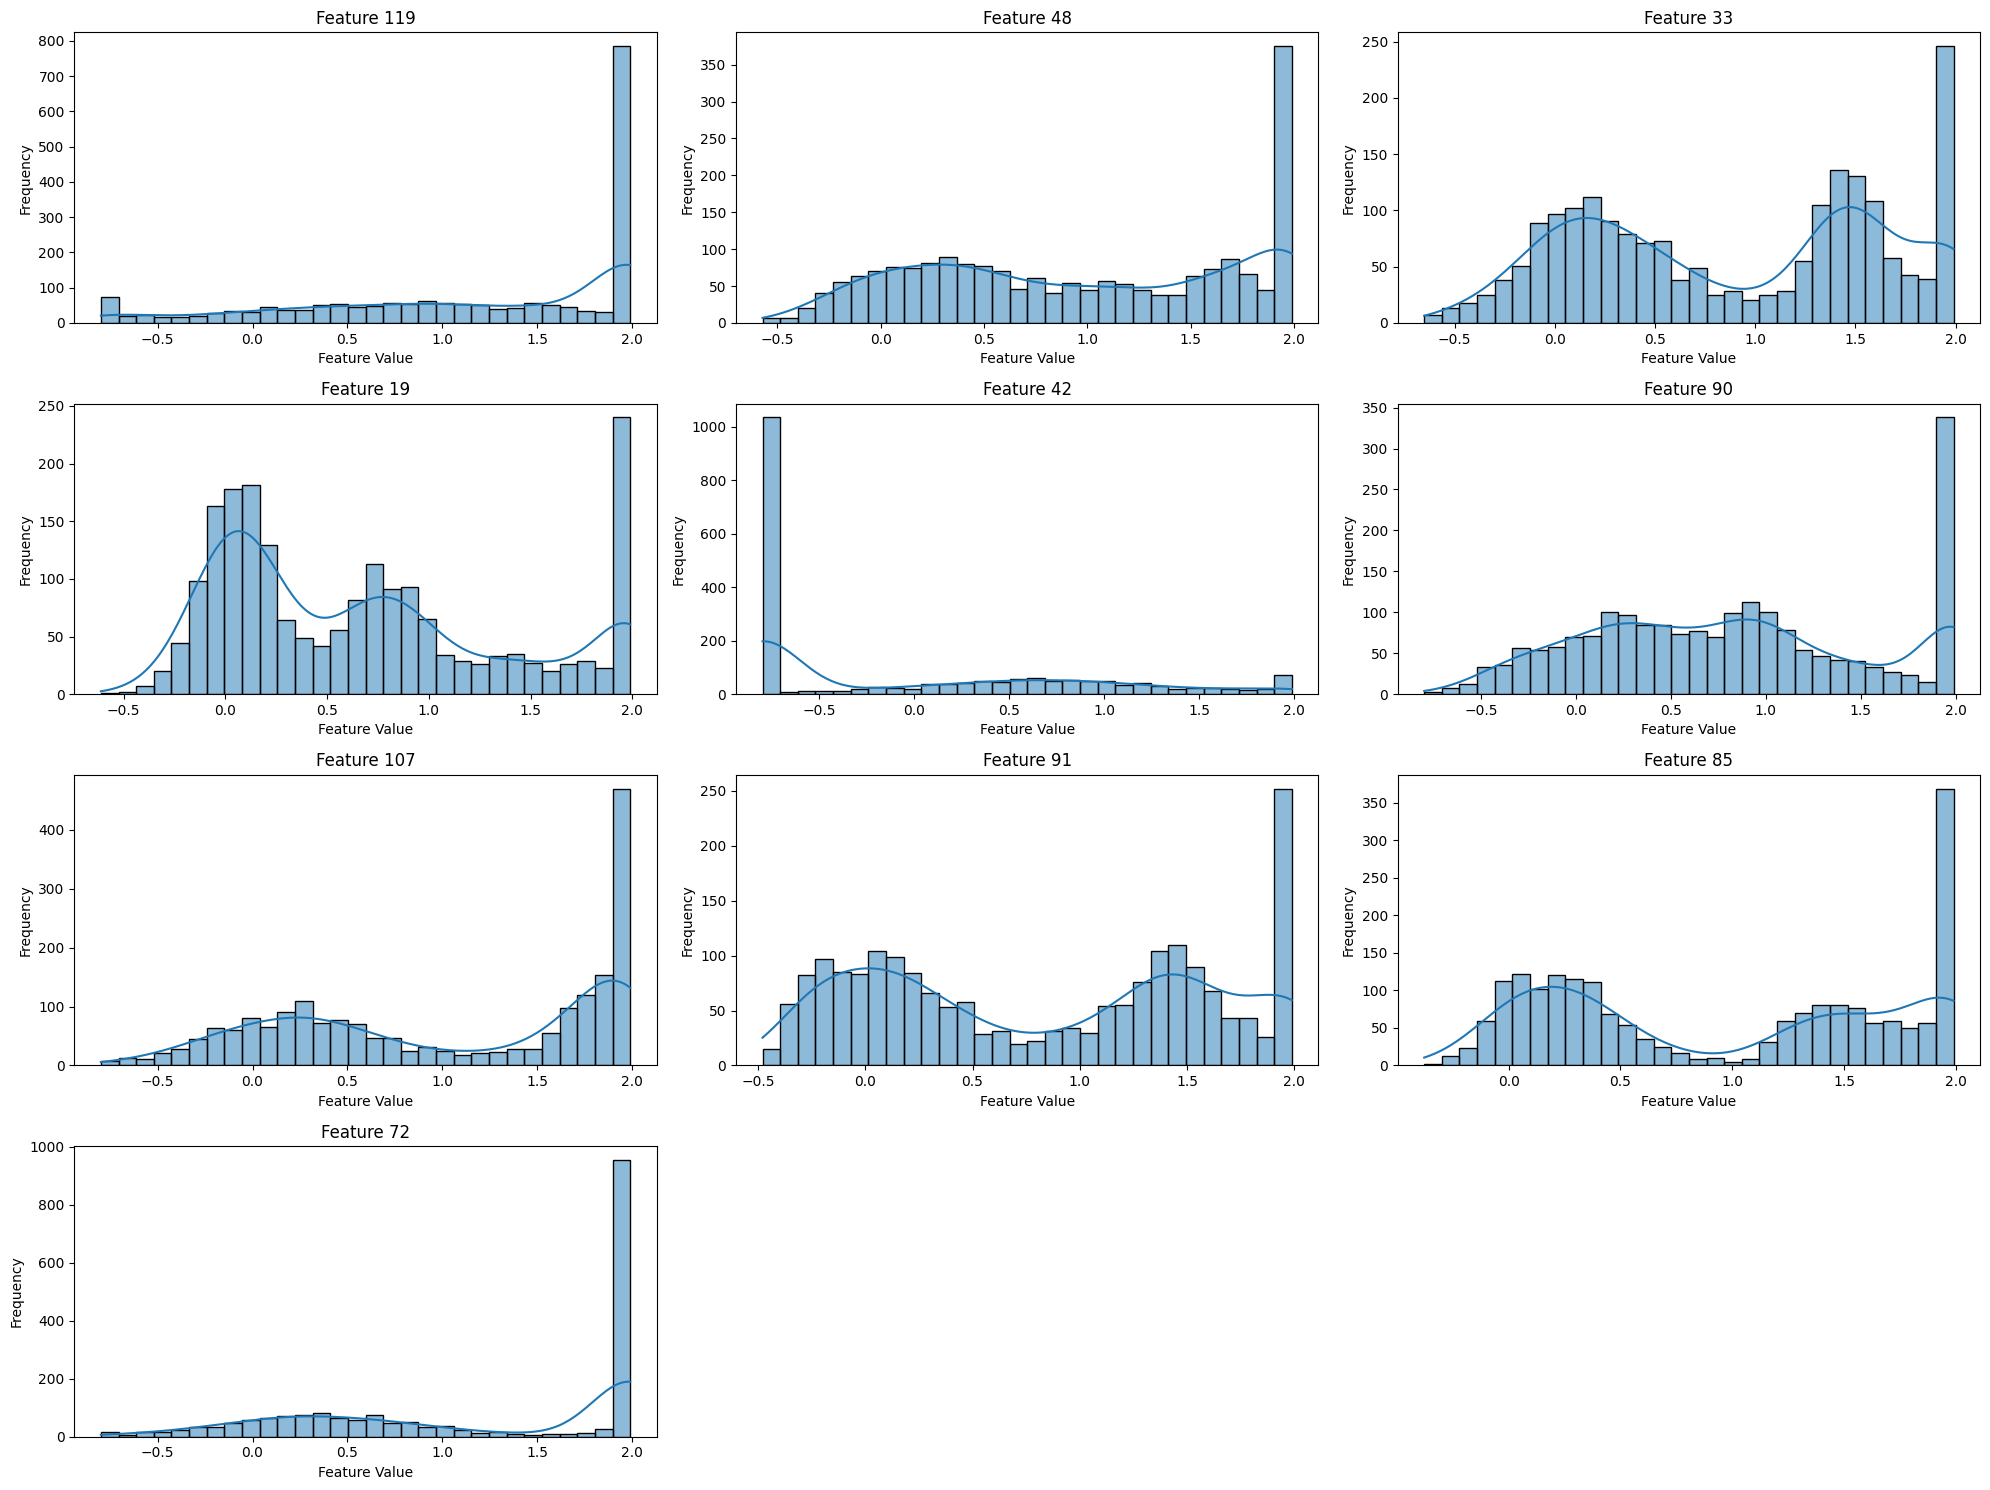

In [136]:
plt.figure(figsize=(20, 15))
for i, feature_index in enumerate(top_feature_indices):
    plt.subplot(4, 3, i + 1)
    sns.histplot(winsorized_features[:, feature_index], kde=True, bins=30)
    plt.title(f'Feature {feature_index}')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

These new distributions look much better and seem to have less overlapping distributions. The best features and their repspective threshold are deemed to be:
- feature 119 threshold 1.5
- feature 33 threshold 1 
- feature 19 threshold 0.5 
- feature 42 threshold -0.5
- feature 107 threshold 1
- feature 91 threshold 0.9
- feature 85 threshold 1 
- feature 72 threshold 1.9 

In [171]:
best_feature_indices = [119, 33, 19, 42, 107, 91, 85, 72]
corresponding_thresholds = [1.5, 1, 0.5, -0.5, 1, 0.9, 1, 1.9]

for feature_index, threshold in zip(best_feature_indices, corresponding_thresholds):
    feature_values = winsorized_features[:, feature_index]
    predictions = (feature_values < threshold).astype(int)

    accuracy = np.mean(predictions == all_labels_np)
    print(f"Accuracy for feature {feature_index} with threshold {threshold}: {accuracy:.4f}")



Accuracy for feature 119 with threshold 1.5: 0.9095
Accuracy for feature 33 with threshold 1: 0.9780
Accuracy for feature 19 with threshold 0.5: 0.9795
Accuracy for feature 42 with threshold -0.5: 0.0315
Accuracy for feature 107 with threshold 1: 0.9765
Accuracy for feature 91 with threshold 0.9: 0.9640
Accuracy for feature 85 with threshold 1: 0.9985
Accuracy for feature 72 with threshold 1.9: 0.9755


Accuracy: 0.9985
Confusion Matrix:
[[998   2]
 [  1 999]]
[ 393 1040 1698]
Image index: 393
Predicted label: 1
True label: 0

Image index: 1040
Predicted label: 0
True label: 1

Image index: 1698
Predicted label: 1
True label: 0



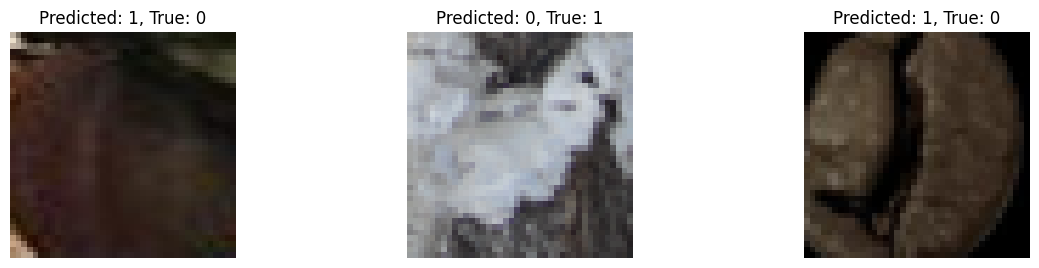

In [181]:
best_feature_index = 85  # As determined to be the best feature
best_feature_values = feature_means_np[:, best_feature_index] 

threshold = 1.0

predictions = (best_feature_values < threshold).astype(int)


accuracy = accuracy_score(all_labels_np, predictions)
report = classification_report(all_labels_np, predictions)
conf_matrix = confusion_matrix(all_labels_np, predictions)

print(f'Feature index: {best_feature_index}')
print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)

misclassified_indices = np.where(predictions != all_labels_np)[0]

for idx in misclassified_indices:
    print(f"Image index: {idx}")
    print(f"Predicted label: {predictions[idx]}")
    print(f"True label: {all_labels_np[idx]}")
    print("")

data_advanced_part = loadmat('matlab/data_a.mat')

data_advanced = data_advanced_part['data_advanced'][0][0]



# The training data has shape (40, 40, 3, 2000), Reshape to (samples, channels, height, widht) = (2000, 40, 40, 3)
data_advanced = np.transpose(data_advanced, (3, 2, 0, 1))
#plot the misclassified images
import matplotlib.pyplot as plt


plt.figure(figsize=(20, 10))
for i, idx in enumerate(misclassified_indices):
    plt.subplot(4, 5, i + 1)
    plt.imshow(data_advanced[idx].transpose(1, 2, 0))
    plt.title(f"Predicted: {predictions[idx]}, True: {all_labels_np[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


Since I can see that features 33, 85 and 107 have similar thresholds I try to add these toghether and look at the plot. 

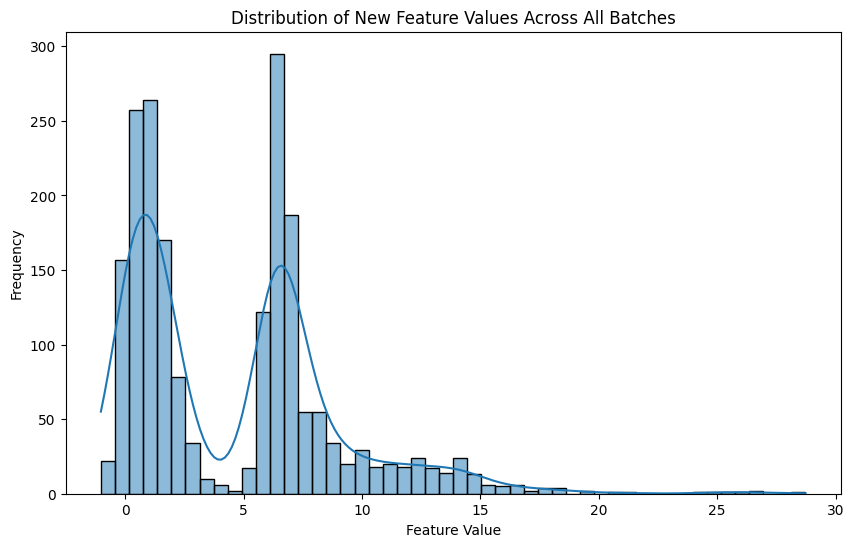

In [172]:
#add together the features 33, 85 and 107
new_feature = feature_means_np[:, 33] + feature_means_np[:, 85] + feature_means_np[:, 107] + feature_means_np[:, 48]


plt.figure(figsize=(10, 6))
sns.histplot(new_feature, bins=50, kde=True)
plt.title("Distribution of New Feature Values Across All Batches")

plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.show()



From this I can choose the threshold 5 

In [173]:

threshold = 5

predictions = (new_feature < threshold).astype(int)

accuracy = accuracy_score(all_labels_np, predictions)
report = classification_report(all_labels_np, predictions)
conf_matrix = confusion_matrix(all_labels_np, predictions)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print('Confusion Matrix:')
print(conf_matrix)


Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:
[[1000    0]
 [   0 1000]]
